In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, pearsonr, spearmanr, chi2_contingency,
    binom, ttest_1samp, ttest_ind, levene, f_oneway
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.outliers_influence import variance_inflation_factor
import time
%matplotlib inline
np.random.seed(42)

# Datasety
IRIS_URL    = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
iris    = pd.read_csv(IRIS_URL)
titanic = pd.read_csv(TITANIC_URL)

# Syntetyczny Housing (fetch_california_housing wymaga połączenia)
np.random.seed(42); n_h = 2000
MedInc  = np.random.exponential(3.5, n_h).clip(0.5, 15)
AveRms  = np.random.normal(5.4, 2.2, n_h).clip(1, 25)
HouseAge= np.random.uniform(1, 52, n_h)
Lat     = np.random.uniform(32.5, 42, n_h)
Lon     = np.random.uniform(-124, -114, n_h)
Popul   = np.random.exponential(1500, n_h).clip(50, 35000)
AveOcc  = np.random.normal(3.0, 1.5, n_h).clip(1, 15)
MedHVal = (0.6*MedInc + 0.05*AveRms - 0.005*HouseAge
           + np.random.normal(0, 0.4, n_h)).clip(0.5, 5)
housing = pd.DataFrame({'MedInc':MedInc,'AveRooms':AveRms,'HouseAge':HouseAge,
                        'Latitude':Lat,'Longitude':Lon,
                        'Population':Popul,'AveOccup':AveOcc,
                        'MedHouseVal':MedHVal})

# Syntetyczne Wine Quality
np.random.seed(42); n_w = 1599
alc   = np.random.normal(10.42, 1.07, n_w).clip(8.4, 14.9)
vacid = np.random.normal(0.528, 0.179, n_w).clip(0.12, 1.58)
sulph = np.random.normal(0.658, 0.170, n_w).clip(0.33, 2.0)
qual_raw = 3 + 0.4*alc - 1.5*vacid + 0.5*sulph + np.random.normal(0, 0.8, n_w)
wine = pd.DataFrame({
    'fixed acidity':         np.random.normal(8.32, 1.74, n_w).clip(4.6, 15.9),
    'volatile acidity':      vacid,
    'citric acid':           np.random.normal(0.271, 0.195, n_w).clip(0, 1),
    'residual sugar':        np.random.exponential(2.5, n_w).clip(1.2, 15.5),
    'chlorides':             np.random.normal(0.087, 0.047, n_w).clip(0.012, 0.611),
    'free sulfur dioxide':   np.random.exponential(15, n_w).clip(1, 72),
    'total sulfur dioxide':  np.random.normal(46.5, 32.9, n_w).clip(6, 289),
    'density':               np.random.normal(0.9967, 0.002, n_w).clip(0.990, 1.004),
    'pH':                    np.random.normal(3.311, 0.154, n_w).clip(2.74, 4.01),
    'sulphates':             sulph,
    'alcohol':               alc,
    'quality':               np.round(np.clip(qual_raw, 3, 8)).astype(int)
})

print(f'Iris: {iris.shape} | Titanic: {titanic.shape}')
print(f'Housing: {housing.shape} | Wine: {wine.shape}')

Iris: (150, 5) | Titanic: (891, 12)
Housing: (2000, 8) | Wine: (1599, 12)


### ✏️ Zadanie 5 – Macierz korelacji

Narysuj heatmap macierzy korelacji dla datasetu California Housing.
Zidentyfikuj 3 pary cech o najwyższej korelacji (poza targetem).

*(proste)*

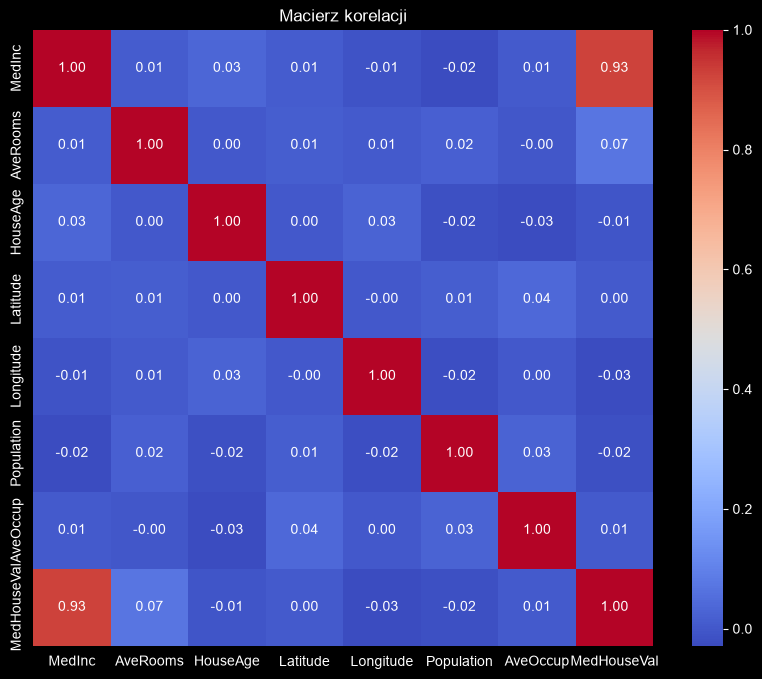

In [4]:
corr = housing.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji")
plt.show()

In [5]:
corr_no_target = corr.drop(index='MedHouseVal', columns='MedHouseVal')

pairs = (
    corr_no_target.where(~np.tril(np.ones(corr_no_target.shape), k=0).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(pairs.head(3))

Latitude  AveOccup    0.036286
MedInc    HouseAge    0.033142
HouseAge  AveOccup   -0.027709
dtype: float64
